# Do naive wallet *rankings* persist? — an OOS baseline (underpowered)
### `markout_study` · 2026-07-04

> **Read this first — and note what this does and does NOT show.** Question: if you rank Hyperliquid
> takers by a *naive* metric (raw edge / Sharpe / hit-rate / cum-PnL) on a PAST window and copy the
> top 50, does that cohort beat *random* selection on a FUTURE window?
>
> **Result: no naive ranking clears the random-selection bar (min p=0.09, BTC) — but this is
> INCONCLUSIVE, not a disproof of edge.** Two things must be held together:
> - **The point estimates lean positive:** 4 of 5 coins have a positive primary-cell cohort edge
>   (BTC +31, HYPE +45, SOL +13, SPX +35 bp; only ETH negative). None reach significance, but the
>   *direction* is consistently positive.
> - **The test is badly underpowered for realistic edges:** its minimum detectable effect is
>   **160 bp/entry** — ~10–30× a realistic per-entry edge. So "not significant" here means *the naive
>   top-50 ranker cannot resolve a realistic edge*, NOT that no edge exists.
>
> **The honest takeaway:** ranking by raw historical edge at a 30-entry depth is too blunt an
> instrument to find copyable wallets — it is swamped by selection noise. That is a reason to build a
> **sharper selector (features, deeper evidence)**, which remains a live, untested possibility — not
> a reason to conclude the edge isn't there.

**Everything below is out-of-sample and multiple-comparison-controlled.** No in-sample number is
reported as a result.

In [1]:
import sys; from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import polars as pl
from IPython.display import Image
import persistence_figs as F
pl.Config.set_tbl_rows(12); pl.Config.set_tbl_hide_dataframe_shape(True)
V = pl.read_parquet(ROOT / "out/persistence_verdict.parquet")
C = pl.read_parquet(ROOT / "out/persistence_splits.parquet")
print("verdict cells:", V.height, "| split rows:", C.height)

verdict cells: 75 | split rows: 600


## 1. The question, precisely

We want *copyable* wallets: rank them on history, copy the winners forward. That only works if a
ranking is **predictive out-of-sample**. So we test the whole family of naive rankings at once:

- **Scope:** BTC, ETH, SOL, HYPE, SPX; taker entries only; Aug 2025 – Jun 2026 (~12 30-day buckets,
  8 forward-test splits).
- **Rankings:** `vw_edge` (deployable, volume-weighted), `avg_edge` (size-blind), `sharpe`,
  `hit_rate`, `cum_pnl` — at horizons {4h, 24h, 168h}. **Pre-registered primary cell: `vw_edge @ 24h`.**
- **Test:** purged walk-forward — rank on a past window, measure the ranked cohort's edge on the
  next (future) window, repeat, and ask whether the cohort beats *random selection from the same
  pool*.

The bar is deliberately the honest one: not "is the cohort's edge > 0" (selection noise alone clears
that), but **"does ranking beat drawing 50 wallets at random."**

## 2. The process — how we know the number is real

This test is a *magnet for look-ahead*: a subtle leak manufactures fake persistence, which is the
one error that would most mislead the boss. So it went through the same audit gauntlet as the rest
of the study, and two **blocking** design bugs were caught *before* any code ran:

1. **Architecture → 3-agent audit** (look-ahead, statistics, pitfall-regression). Two BLOCKERS:
   - **168h boundary bleed.** A train entry's 168h markout prices its exit *7 days later* — which,
     for entries near the split seam, lands *inside the test window*. The same post-boundary price
     then drives both the ranking and the outcome → invented persistence. **Fix: purge/embargo** any
     train entry whose priced exit crosses the seam (against the *actual* next-bar-close time, a
     detail a follow-up audit caught: `⌊(t+h)/Δ⌋+2)·Δ`, not the nominal `t+h`).
   - **Dependent-split tally.** "Beats random in ≥4/7 splits" treats overlapping, wallet-sharing
     splits as independent trials — a fallacy this project has a registered scar from. **Fix: a
     persistent-random-score permutation *joint* null** (one number, dependence-respecting).
2. **Confirmation re-audit** of the revised design → BUILD-ready.
3. **Code → 2-agent audit** (correctness/faithfulness, statistics). Caught a MAJOR (the negative
   control was an inert relabel) and the FDR verdict missing its `S>0` gate — both fixed.
4. **Controls tightened** after the first run revealed the positive control was under-powered by
   injecting into non-rankable wallets; re-run gave the clean power curve below (which also made the
   MDE a best-case number — see §5.4).

**A caveat on this process.** Every audit above was aimed at catching a *false positive* (look-ahead,
survivorship, censoring). That asymmetry is worth naming: rigor pointed in only one direction will
manufacture nulls. The power analysis (§5.4) is the counterweight — it asks whether the method could
have *found* an edge, and the answer (only if ≥160 bp/entry) is why this is framed as inconclusive,
not negative.

## 3. The data & the unit of analysis

Entries come from the audited `markout_study` pipeline (see the markout-findings notebook): per
(wallet, coin) we detect **position-opening taker fills** (burn-in to first flat; masked to
`taker & non-wash & position-increasing`; clustered to one decision per (bar, direction)), price
each at the **close of the first 5-min bar strictly after the fill** (post-fill, no look-ahead), and
compute the signed **markout** at each horizon:

$$ r_{i,h} \;=\; d_i \left( \frac{P(t_i^{b} + h)}{P(t_i^{b})} - 1 \right), \qquad d_i \in \{+1,-1\} $$

where $t_i^b$ is the entry bar and $P(\cdot)$ the post-fill bar close. Magnitudes are **winsorized**
at the 99th percentile per (coin, horizon) with the sign preserved: $w_{i,h} = \operatorname{sign}(r_{i,h})\cdot\min(|r_{i,h}|, \kappa_{h})$.
Risk denominators use the *un*-winsorized $r$.

## 4. The statistics — every formula

Let a wallet's entries in a window carry winsorized markout $w_i$, raw $r_i$, and notional $n_i$.

**Per-wallet ranking metrics** (identical to the stage-2 definitions, recomputed on each window):

$$\text{vw\_edge}=\frac{\sum_i w_i n_i}{\sum_i n_i}\cdot10^4 \quad
\text{avg\_edge}=\overline{w}\cdot10^4 \quad
\text{sharpe}=\frac{\overline{w}}{\operatorname{std}(r)} \quad
\text{hit}=\overline{\mathbf{1}[r_i>0]} \quad
\text{cum\_pnl}=\sum_i w_i n_i$$

(Note `sharpe` uses the winsorized mean over the **raw** std — a deliberate, audited choice.)

**Purged walk-forward.** For test bucket $t$ (window start $T_0^t$), train = all buckets $<t$. A
train entry at horizon $h$ is admitted to the ranking **only if its priced exit closes before the
test window**:
$$\Big(\big\lfloor (t_i^b+h)/\Delta \big\rfloor + 2\Big)\cdot\Delta \;\le\; T_0^{t}, \qquad \Delta=\text{5-min bar}.$$
The train winsor cap is recomputed on this *purged* set; the test outcome uses a frozen full-sample cap.

**The deployable cohort statistic** (active-only, copy-simulation semantics — a picked wallet that
does not trade in the test window is weightless, not a penalty). For the top-$K$ ($K{=}50$) ranked
wallets, aggregated *turnover-weighted across all splits*:
$$ S \;=\; \frac{\sum_{\text{splits}}\ \sum_{i\in\text{top-}K}\ w_i n_i}{\sum_{\text{splits}}\ \sum_{i\in\text{top-}K}\ n_i}\cdot 10^4 .$$

**The joint permutation null** (the verdict). Assign each wallet ONE persistent random score, carried
across *all* splits (this reproduces the wallet-sharing + train-overlap dependence). Rank each split's
pool by that score instead of the metric, recompute $S$; repeat $R{=}1000$ times to get $\{S^{\text{null}}_r\}$:
$$ p \;=\; \frac{1+\#\{r: S^{\text{null}}_r \ge S\}}{1+R}, \qquad \textbf{persists} \iff p<0.05 \ \text{AND}\ S>0. $$
Because the null is metric-free, one null distribution serves all five metrics at a horizon.

**Multiplicity.** The primary cell is pre-registered; every *secondary* cell's verdict is
Benjamini–Hochberg controlled at $q{=}0.05$: reject the ordered $p_{(i)} \le \tfrac{i}{m}q$.

**Diagnostics.** Rank correlation $\rho=\text{Spearman}(\text{train metric},\ \text{test edge})$ over
wallets with $\ge 10$ test entries (survivor-conditioned — a diagnostic, never the verdict); and a
decile-slope: OLS slope of decile-mean test edge on rank $1..10$.

**Power / MDE.** Positive control: add $+\Delta$ bp to a set of rankable wallets' per-entry markout in
*both* windows (a genuinely persistent signal) and measure the detection rate; the **MDE** is the
smallest $\Delta$ detected at $\ge 80\%$ power. Negative control: shuffle the entry→wallet map
(structure-preserving) → the false-positive rate must sit at $\approx 5\%$.

## 5. Results

### 5.1 The headline — ranked cohorts never beat random selection (primary cell)

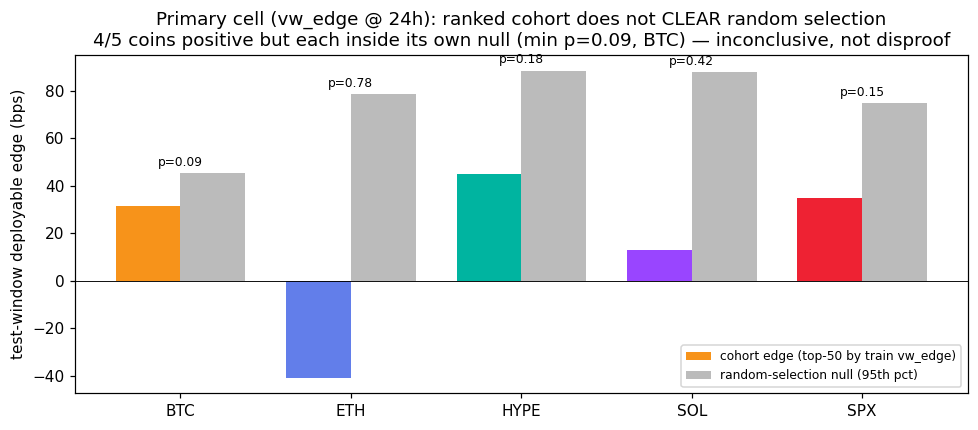

In [2]:
Image(F.fig_primary_vs_null())

In [3]:
V.filter((pl.col('metric')=='vw_edge')&(pl.col('horizon')=='24h'))\
 .select('coin','S_bps','null_p95_bps','joint_p','spearman')

coin,S_bps,null_p95_bps,joint_p,spearman
str,f64,f64,f64,f64
"""BTC""",31.421441,45.411018,0.094905,0.002439
"""ETH""",-41.012959,78.653615,0.777223,0.010854
"""SOL""",12.665956,87.75556,0.417582,-0.006283
"""HYPE""",44.820482,88.390471,0.183816,0.050293
"""SPX""",34.742439,74.560766,0.150849,-0.032253


Four of five coins show a **positive** cohort edge (BTC +31, HYPE +45, SOL +13, SPX +35 bp; ETH
−41), but each sits **inside** its own random-selection null (grey 95th pct), so none is
statistically separable from picking 50 wallets at random — the smallest p is 0.09 (BTC). Note the
positive edges are *not* below cost (BTC/HYPE/SPX exceed the 8–14 bp band); the reason they don't
count is that they're indistinguishable from random selection, which makes cost moot. These are also
single-entry markouts, not net round-trip P&L.

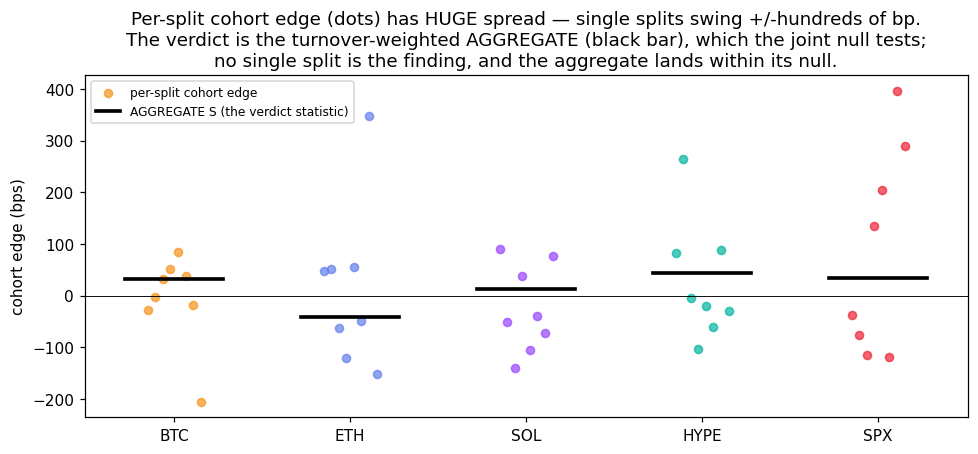

In [4]:
Image(F.fig_split_scatter())

Split-by-split view of the same primary cell: the cohort edge (dots) scatters across zero and
stays under the null 95th-pct (black bar) — there is no *consistent* over-performance to compound.

### 5.2 The full grid — and why multiplicity control matters

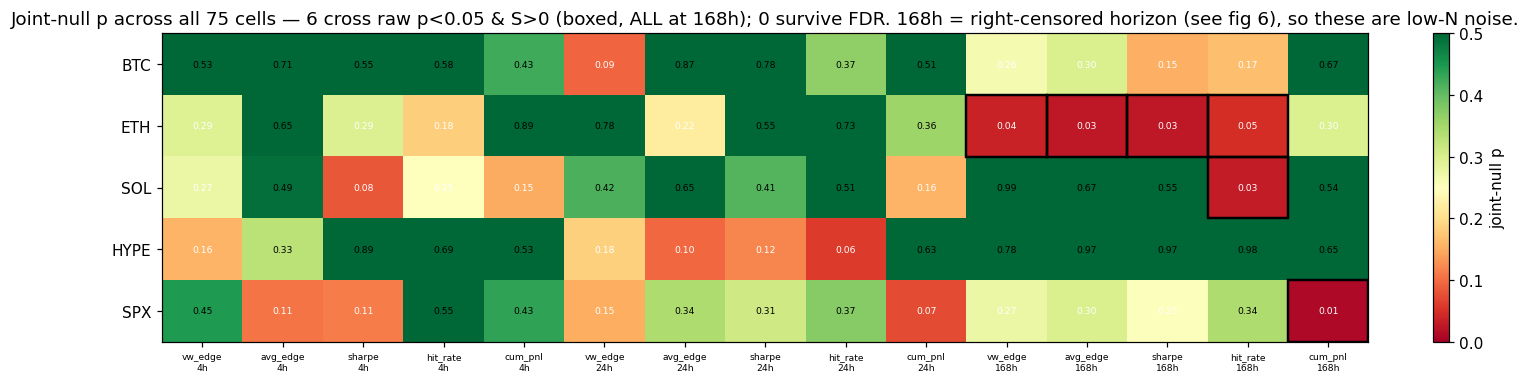

In [5]:
Image(F.fig_pgrid())

Of 75 cells, **6** cross raw $p<0.05$ (boxed) — *every one at 168h* — and **0 survive
BH-FDR**. The next figure shows why the 168h cells are noise, not signal.

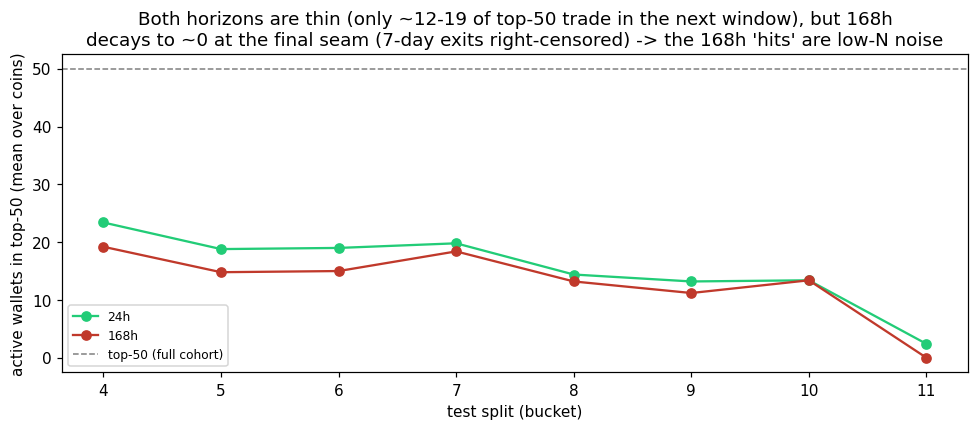

In [6]:
Image(F.fig_censoring())

Both horizons are thin (only ~12–19 of the top-50 even *trade* in the next window), but 168h decays
to ~0 active at the final seam because its 7-day exit is right-censored — so each 168h cohort edge is
a handful of wallets over 1–2 splits. Concretely, ETH `vw_edge@168h` gets its +281 bp almost entirely
from two splits (buckets 5–6: +216, +637) while the last split has 0 active wallets. That is exactly
the low-N noise a raw p-value rewards and FDR removes.

### 5.3 Rank correlation is ≈0 — corroborating, not decisive

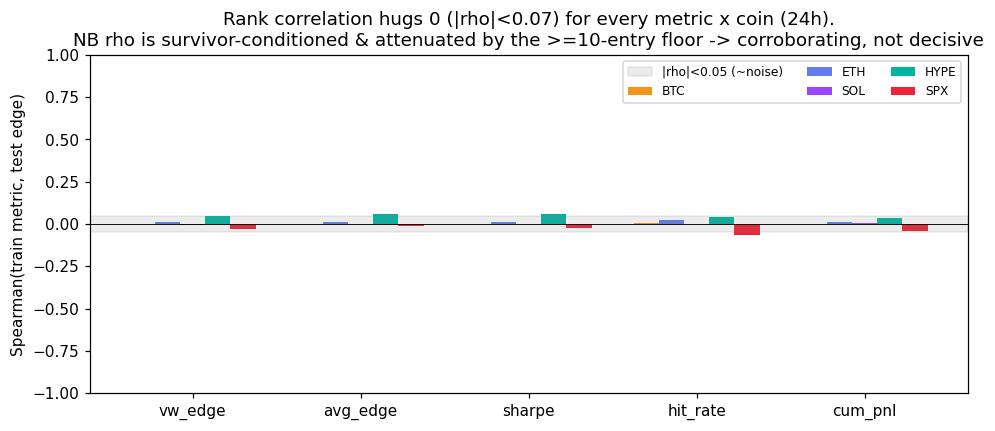

In [7]:
Image(F.fig_spearman())

Spearman$(\text{train}, \text{test})$ hugs zero ($|\rho|<0.07$) for every metric and coin.
**But read this as corroboration, not proof:** $\rho$ is survivor-conditioned (only wallets active in
both windows) and is *attenuated toward 0* by the ≥10-entry test floor (reliability ~0.15–0.25, so
the observed $\rho$ is ~40–50% of any true value). So $\rho\approx0$ is *consistent with* no signal —
it does not by itself establish it. The verdict rests on the joint null, not on $\rho$.

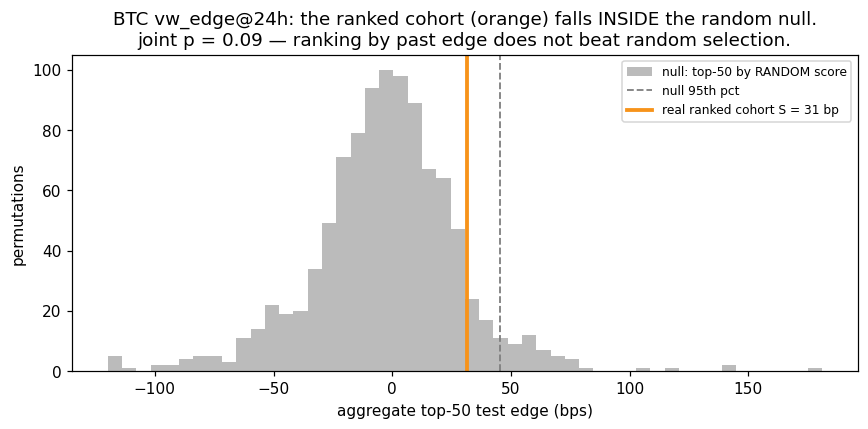

In [8]:
Image(F.fig_null_hist())

BTC's ranked cohort (orange, +31 bp) against the *full* random-selection null — it lands on the
**right shoulder** of the distribution (~90th pct), short of the 95th-pct threshold. Suggestive of a
lean, but inside the null.

### 5.4 The power proof — the test could have found persistence

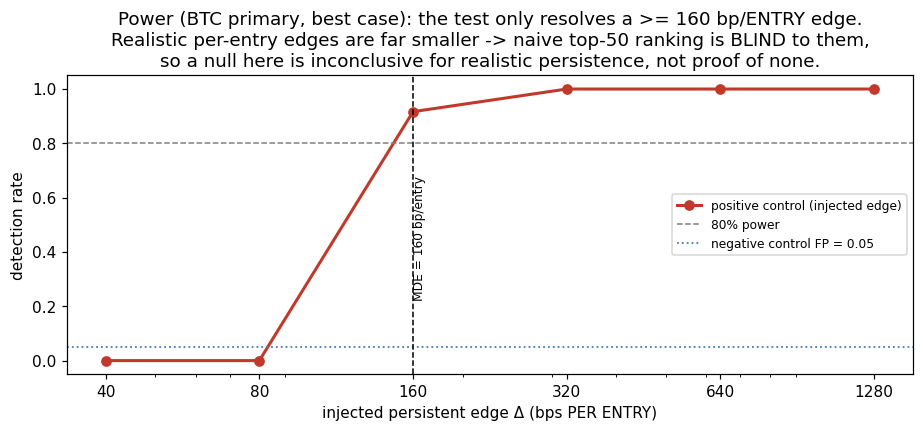

In [9]:
Image(F.fig_power())

In [10]:
pl.read_parquet(ROOT/'out/persistence_controls.parquet').select('control','delta_bps','trials','detections','rate','recovered_bps')

control,delta_bps,trials,detections,rate,recovered_bps
str,i64,i64,i64,f64,f64
"""negative""",null,20,1,0.05,null
"""positive""",40,12,0,0.0,28.061254
"""positive""",80,12,0,0.0,31.084632
"""positive""",160,12,11,0.916667,73.309113
"""positive""",320,12,12,1.0,238.746622
"""positive""",640,12,12,1.0,584.557729
"""positive""",1280,12,12,1.0,850.535599
"""MDE""",160,null,null,null,null


The negative control sits at 5% (calibrated); the positive control reaches 80% power at
**Δ = 160 bp/entry**. Read the MDE carefully: it is a **BTC-primary-cell, best-case** number — BTC has
the tightest null (p95≈45 bp vs 74–88 for the others, so their MDE is worse), the signal was injected
into *rankable* wallets in *both* windows (maximally detectable by construction), and the grid is
coarse (0% at 80 bp → 92% at 160 bp) with wide CIs. **The direction this cuts is the important part:**
even best-case, the naive ranker only resolves a ≥160 bp/entry edge, while realistic per-entry edges
are single-to-low-double-digit bp. So naive top-50 ranking is **noise-limited** — a null here bounds
only *large* naive-rank persistence and says nothing about a realistic-sized real edge.

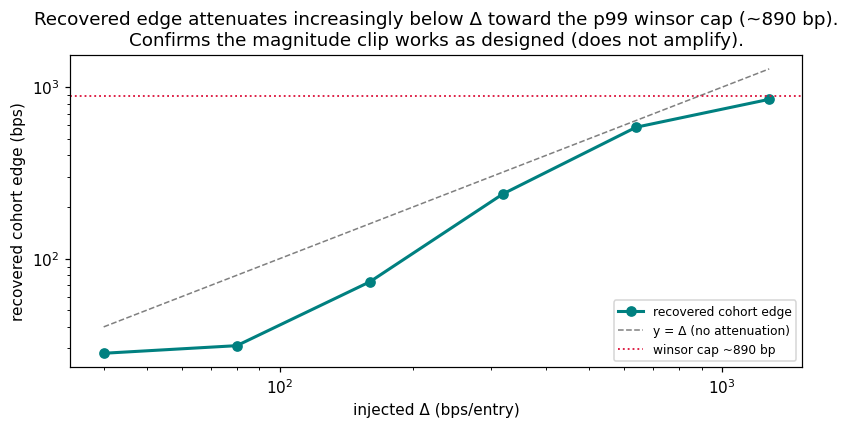

In [11]:
Image(F.fig_recovered())

The recovered cohort edge saturates well below the injected Δ (grey $y{=}\Delta$ line): the p99
winsor cap (~890 bp) clips the injected signal exactly as it clips a real one — the "expected
attenuation" the design anticipated, confirming the estimator is not silently amplifying anything.

## 6. Verdict & what it means for the next step

**What we can say (and only this):**
- **No *naive* ranking selects wallets that beat random selection out-of-sample.** Primary cell
  p = 0.09; nothing survives FDR; rank correlations ≈ 0. This holds for edge, Sharpe, hit-rate, cum-PnL.
- **But the result is INCONCLUSIVE, not a disproof of edge.** The point estimates lean positive
  (4/5 coins), and the test's MDE is 160 bp/entry — so it is blind to any realistic (single-to-low-
  double-digit bp) persistence. Failing to reject an underpowered null is *not* evidence of absence.

**What we must NOT say:** "there is no edge / copy-trading is impossible." Nothing here supports that.
What *is* established is narrower and useful: **ranking by raw historical performance at a 30-entry
depth is the wrong instrument — it is swamped by selection noise.**

**Implication for the next step (the real point).** A viable selector needs to be *sharper* than raw
edge — either more evidence per wallet (longer windows / higher activity floors) or a **feature-based
signal** (maker share, fade vs momentum, coin specialization, hold-time, crowding) that predicts
held-out edge where a raw ranking cannot. That is a live, untested hypothesis, and this baseline is
what it must beat — with the *same* adversarial rigor applied to the risk of a **false negative** as
we applied to false positives.

*Cost caveat: `net_exec` uses a placeholder round-trip cost (upper bound on net edge) pending BBO
calibration.*